YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
/opt/homebrew/Caskroom/miniconda/base/envs/trading-env/lib/python3.11/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


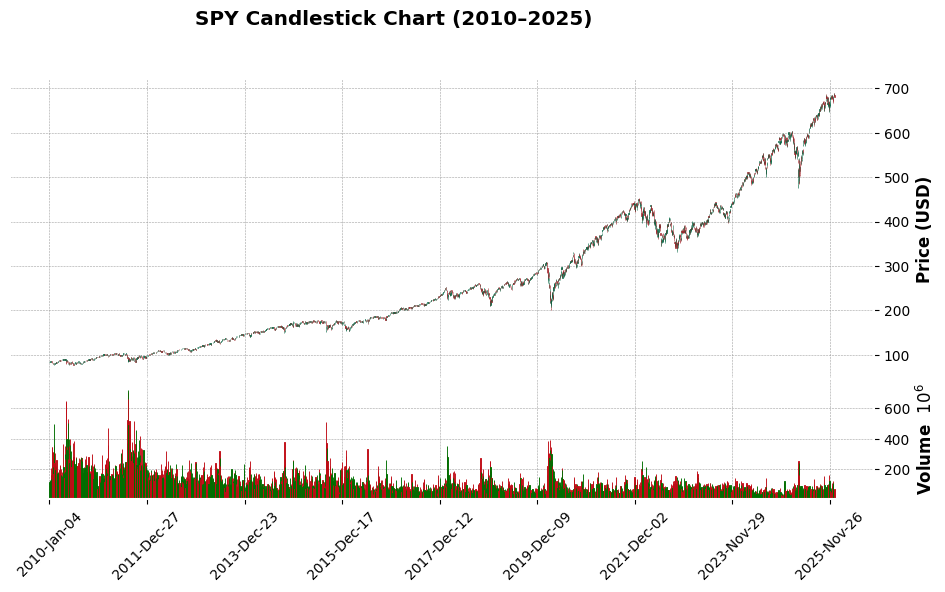

In [1]:
import yfinance as yf
import mplfinance as mpf

# Download data
data = yf.download('SPY', start='2010-01-01', end='2026-01-01', interval='1d')

# FIX: remove MultiIndex
data.columns = data.columns.droplevel(1)

# (Optional sanity check)
print(data.columns)

# Plot
mpf.plot(
    data,
    type='candle',
    style='charles',
    title='SPY Candlestick Chart (2010–2025)',
    ylabel='Price (USD)',
    volume=True,
    figsize=(12, 6)
)

In [5]:
from finrl import config
from finrl import config_tickers
from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.preprocessor.preprocessors import FeatureEngineer, data_split
from finrl.meta.env_portfolio_allocation.env_portfolio import StockPortfolioEnv
from finrl.agents.stablebaselines3.models import DRLAgent
from finrl.plot import backtest_stats, backtest_plot, get_daily_return, get_baseline,convert_daily_return_to_pyfolio_ts
from finrl.meta.data_processor import DataProcessor
from finrl.meta.data_processors.processor_yahoofinance import YahooFinanceProcessor
import sys

/opt/homebrew/Caskroom/miniconda/base/envs/trading-env/lib/python3.11/site-packages/pyfolio/pos.py:25: UserWarning: Module "zipline.assets" not found; multipliers will not be applied to position notionals.
  warnings.warn(


In [46]:
dp = YahooFinanceProcessor()
df = dp.download_data(start_date = '2020-01-01',
                     end_date = '2021-01-01',
                     ticker_list = ['SPY'], time_interval='1D')

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['SPY']: YFPricesMissingError('possibly delisted; no price data found  (1d 2020-01-01 00:00:00 -> 2020-01-02 00:00:00)')
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['SPY']: YFPricesMissingError('possibly delisted; no price data found  (1d 2020-01-04 00:00:00 -> 2020-01-05 00:00:00)')
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['SPY']: YFPricesMissingError('possibly delisted; no price data found  (1d 2020-01-05 00:00:00 -> 2020-01-06 00:00:00)')
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100

In [51]:
df.to_csv('SPY.csv', index=False)

In [26]:
data['Close'].head()

Date
2010-01-04    84.796387
2010-01-05    85.020844
2010-01-06    85.080704
2010-01-07    85.439896
2010-01-08    85.724182
Name: Close, dtype: float64

In [27]:
data['Open'].head()

Date
2010-01-04    84.078091
2010-01-05    84.744004
2010-01-06    84.938539
2010-01-07    84.923618
2010-01-08    85.215389
Name: Open, dtype: float64

In [28]:
data

Price,Close,High,Low,Open,Volume
Date,,,,,
2010-01-04,84.796387,84.841278,83.434617,84.078091,118944600
2010-01-05,85.020844,85.058257,84.437229,84.744004,111579900
2010-01-06,85.080704,85.290206,84.871202,84.938539,116074400
2010-01-07,85.439896,85.544647,84.684186,84.923618,131091100
2010-01-08,85.724182,85.761596,85.043300,85.215389,126402800
...,...,...,...,...,...
2025-12-24,688.499695,688.948481,685.926705,686.076320,39445600
2025-12-26,688.429871,689.776169,687.392725,688.758989,41613300
2025-12-29,685.976562,687.322922,684.201442,685.667409,62559500


In [34]:
data['Close'][1:3]

Date
2010-01-05    85.020844
2010-01-06    85.080704
Name: Close, dtype: float64

In [54]:
data_reset = data.reset_index()
data_reset = data_reset.rename(columns={'Date': 'date', 'Open': 'open', 'High': 'high', 'Low': 'low', 'Close': 'close', 'Volume': 'volume'})
new_row = pd.DataFrame([{'tic': 'SPY'}])

# Use concat instead of append
data_reset = pd.concat([data_reset, new_row], ignore_index=True)

data_reset

,date,close,high,low,open,volume,tic
0,2010-01-04,84.796387,84.841278,83.434617,84.078091,118944600.0,NaN
1,2010-01-05,85.020844,85.058257,84.437229,84.744004,111579900.0,NaN
2,2010-01-06,85.080704,85.290206,84.871202,84.938539,116074400.0,NaN
3,2010-01-07,85.439896,85.544647,84.684186,84.923618,131091100.0,NaN
4,2010-01-08,85.724182,85.761596,85.043300,85.215389,126402800.0,NaN
...,...,...,...,...,...,...,...
4020,2025-12-26,688.429871,689.776169,687.392725,688.758989,41613300.0,NaN
4021,2025-12-29,685.976562,687.322922,684.201442,685.667409,62559500.0,NaN
4022,2025-12-30,685.138916,686.684682,684.710094,685.577720,47160700.0,NaN
4023,2025-12-31,680.062744,685.487930,679.853355,685.268559,74144800.0,NaN


In [52]:
data_reset.to_csv('SPY_reset.csv', index=False)

In [1]:
import pandas as pd

df = pd.read_csv('./data/raw/SPY.csv')

df

,date,close,high,low,open,volume,tic,day
0,2010-01-04,84.796371,84.841263,83.434602,84.078076,118944600,SPY,0
1,2010-01-05,85.020821,85.058234,84.437206,84.743981,111579900,SPY,1
2,2010-01-06,85.080696,85.290198,84.871194,84.938531,116074400,SPY,2
3,2010-01-07,85.439835,85.544586,84.684126,84.923557,131091100,SPY,3
4,2010-01-08,85.724182,85.761596,85.043300,85.215389,126402800,SPY,4
...,...,...,...,...,...,...,...,...
4018,2025-12-23,686.086304,686.325640,682.007416,682.057268,64840000,SPY,1
4019,2025-12-24,688.499695,688.948481,685.926705,686.076320,39445600,SPY,2
4020,2025-12-26,688.429871,689.776169,687.392725,688.758989,41613300,SPY,4
4021,2025-12-29,685.976562,687.322922,684.201442,685.667409,62559500,SPY,0


In [5]:
corr = df[[ 'close' , 'open' , 'high' , 'low' , 'volume']].corr()
print(corr)

           close      open      high       low    volume
close   1.000000  0.999859  0.999920  0.999924 -0.491100
open    0.999859  1.000000  0.999931  0.999923 -0.489979
high    0.999920  0.999931  1.000000  0.999870 -0.487428
low     0.999924  0.999923  0.999870  1.000000 -0.493775
volume -0.491100 -0.489979 -0.487428 -0.493775  1.000000


In [6]:
df[[ 'close' , 'open' , 'high' , 'low' , 'volume']].describe()

,close,open,high,low,volume
count,4023.000000,4023.000000,4023.000000,4023.000000,4.023000e+03
mean,267.967762,267.918626,269.356386,266.349136,1.093688e+08
std,155.480152,155.457920,156.246589,154.571001,6.797125e+07
min,77.148857,77.835802,78.069813,76.341134,2.027000e+07
25%,146.221710,146.315720,146.671158,145.843104,6.523535e+07
50%,227.698715,227.959560,230.945647,226.066944,8.943310e+07
75%,386.301971,385.720946,388.484856,383.569881,1.328858e+08
max,688.499695,688.758989,689.776169,687.392725,7.178287e+08


close        Axes(0.125,0.653529;0.352273x0.226471)
open      Axes(0.547727,0.653529;0.352273x0.226471)
high         Axes(0.125,0.381765;0.352273x0.226471)
low       Axes(0.547727,0.381765;0.352273x0.226471)
volume           Axes(0.125,0.11;0.352273x0.226471)
dtype: object

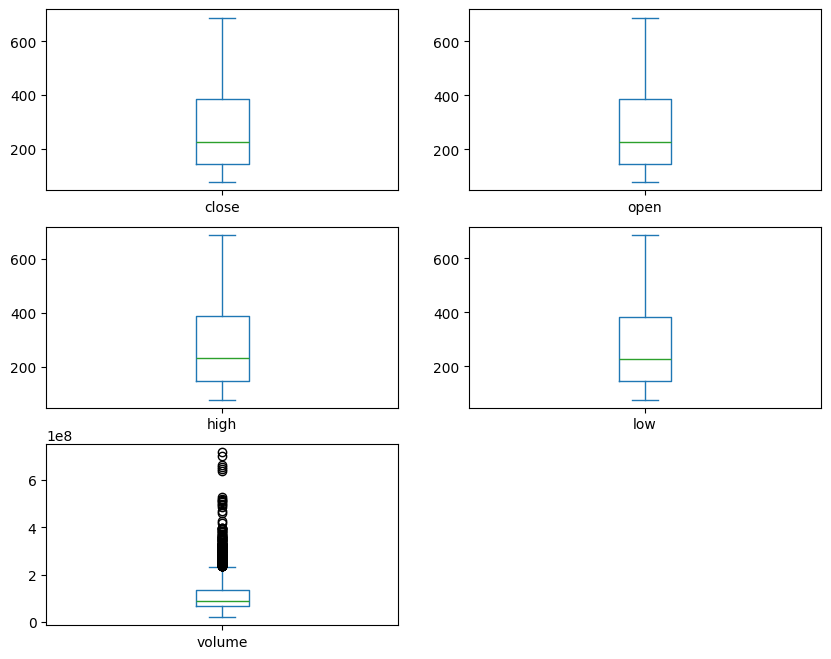

In [9]:
df[[ 'close' , 'open' , 'high' , 'low' , 'volume']].plot(kind='box', subplots=True, layout=(3, 2), figsize=(10, 8))

In [15]:
df = pd.read_csv('./data/processed/SPY/test.csv')

df.columns

Index(['date', 'close', 'high', 'low', 'open', 'volume', 'tic', 'day',
       'ret_1d', 'ret_5d', 'rsi_14', 'sma_ratio', 'vol_20d', 'vol_ratio'],
      dtype='object')

In [17]:
data = df[['ret_1d', 'ret_5d', 'rsi_14', 'sma_ratio', 'vol_20d', 'vol_ratio']]

data.describe()

,ret_1d,ret_5d,rsi_14,sma_ratio,vol_20d,vol_ratio
count,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000
mean,0.019882,0.048622,0.142605,0.094174,-0.009884,-0.003979
std,0.966440,0.940089,0.955525,0.878365,0.915339,0.935025
min,-5.543944,-5.380482,-3.132905,-4.614276,-0.920901,-1.683986
25%,-0.349608,-0.402235,-0.365192,-0.172032,-0.457029,-0.593842
50%,0.044859,0.124154,0.272238,0.263000,-0.222773,-0.191656
75%,0.481761,0.548829,0.848021,0.584754,0.043661,0.343994
max,9.781597,3.634620,2.250635,2.519227,4.245771,5.548099
